# FastSurfer Feature Aggregation

Reduces the ~2700-column per-subject FastSurfer output to **11 aggregate features** per subject, restricted to participants that also have paired HUNT3+HUNT4 MRI data:

| Feature | Description |
|---|---|
| `wmh_volume` | Total WM-hypointensity volume (mm³) |
| `{lobe}_thickness_mean` | Surface-area-weighted mean cortical thickness across all DK parcels in that lobe (mm) |
| `{lobe}_volume_total` | Total cortical gray-matter volume for that lobe (mm³) |

**Lobes (5):** frontal (13 DK parcels), parietal (7), temporal (9), occipital (4), insula (1 — kept separate to match FreeSurfer `lobesStrict`).

**NaN handling:** string `'NaN '` values in the raw files are coerced to true NaN; subjects where any output feature is still NaN after aggregation are dropped.

## Setup

In [1]:
import sys
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from utils.fastsurfer_aggregator import FastSurferAggregator, LOBE_REGIONS

In [2]:
SMRI_DIR      = 'data/metadata/hdd/sMRI'
OUT_PATH      = 'data/metadata/fastsurfer_aggregated.csv'
OUT_PATH_NORM = 'data/metadata/fastsurfer_aggregated_normalized.csv'

LOBES = ['frontal', 'parietal', 'temporal', 'occipital', 'insula']
LOBE_COLORS = {
    'frontal':  '#4878d0',
    'parietal': '#ee854a',
    'temporal': '#6acc65',
    'occipital':'#d65f5f',
    'insula':   '#956cb4',
}

---
## Part 1 — Lobe Mapping (Desikan-Killiany Atlas)

Each of the 34 DK parcels per hemisphere is assigned to exactly one lobe.
Cingulate sub-regions follow the standard neuroimaging convention:
anterior cingulate → frontal; posterior/isthmus cingulate → parietal.

In [3]:
rows = []
for lobe, regions in LOBE_REGIONS.items():
    for r in regions:
        rows.append({'Lobe': lobe.capitalize(), 'DK parcel': r,
                     'Thickness cols': f'cort_thick-ctx-{{lh,rh}}-{r}',
                     'Volume cols': f'cort_vol-ctx-{{lh,rh}}-{r}'})

mapping_df = pd.DataFrame(rows)
print(f'Total DK parcels per hemisphere: {len(rows)} (× 2 hemispheres = {len(rows)*2} columns per measure)')
display(mapping_df.set_index(['Lobe','DK parcel']))

Total DK parcels per hemisphere: 34 (× 2 hemispheres = 68 columns per measure)


Thickness cols  \
Lobe      DK parcel                                                                   
Frontal   caudalanteriorcingulate    cort_thick-ctx-{lh,rh}-caudalanteriorcingulate   
          caudalmiddlefrontal            cort_thick-ctx-{lh,rh}-caudalmiddlefrontal   
          lateralorbitofrontal          cort_thick-ctx-{lh,rh}-lateralorbitofrontal   
          medialorbitofrontal            cort_thick-ctx-{lh,rh}-medialorbitofrontal   
          paracentral                            cort_thick-ctx-{lh,rh}-paracentral   
          parsopercularis                    cort_thick-ctx-{lh,rh}-parsopercularis   
          parsorbitalis                        cort_thick-ctx-{lh,rh}-parsorbitalis   
          parstriangularis                  cort_thick-ctx-{lh,rh}-parstriangularis   
          precentral                              cort_thick-ctx-{lh,rh}-precentral   
          rostralanteriorcingulate  cort_thick-ctx-{lh,rh}-rostralanteriorcingulate   
          rostralmiddlefrontal          cort_thick-ctx-{lh,rh}-rostralmiddlefrontal   
          superiorfrontal                    cort_thick-ctx-{lh,rh}-superiorfrontal   
          frontalpole                            cort_thick-ctx-{lh,rh}-frontalpole   
Parietal  inferiorparietal                  cort_thick-ctx-{lh,rh}-inferiorparietal   
          isthmuscingulate                  cort_thick-ctx-{lh,rh}-isthmuscingulate   
          postcentral                            cort_thick-ctx-{lh,rh}-postcentral   
          posteriorcingulate              cort_thick-ctx-{lh,rh}-posteriorcingulate   
          precuneus                                cort_thick-ctx-{lh,rh}-precuneus   
          superiorparietal                  cort_thick-ctx-{lh,rh}-superiorparietal   
          supramarginal                        cort_thick-ctx-{lh,rh}-supramarginal   
Temporal  bankssts                                  cort_thick-ctx-{lh,rh}-bankssts   
          entorhinal                              cort_thick-ctx-{lh,rh}-entorhinal   
          fusiform                                  cort_thick-ctx-{lh,rh}-fusiform   
          inferiortemporal                  cort_thick-ctx-{lh,rh}-inferiortemporal   
          middletemporal                      cort_thick-ctx-{lh,rh}-middletemporal   
          parahippocampal                    cort_thick-ctx-{lh,rh}-parahippocampal   
          superiortemporal                  cort_thick-ctx-{lh,rh}-superiortemporal   
          temporalpole                          cort_thick-ctx-{lh,rh}-temporalpole   
          transversetemporal              cort_thick-ctx-{lh,rh}-transversetemporal   
Occipital cuneus                                      cort_thick-ctx-{lh,rh}-cuneus   
          lateraloccipital                  cort_thick-ctx-{lh,rh}-lateraloccipital   
          lingual                                    cort_thick-ctx-{lh,rh}-lingual   
          pericalcarine                        cort_thick-ctx-{lh,rh}-pericalcarine   
Insula    insula                                      cort_thick-ctx-{lh,rh}-insula   

                                                                      Volume cols  
Lobe      DK parcel                                                                
Frontal   caudalanteriorcingulate    cort_vol-ctx-{lh,rh}-caudalanteriorcingulate  
          caudalmiddlefrontal            cort_vol-ctx-{lh,rh}-caudalmiddlefrontal  
          lateralorbitofrontal          cort_vol-ctx-{lh,rh}-lateralorbitofrontal  
          medialorbitofrontal            cort_vol-ctx-{lh,rh}-medialorbitofrontal  
          paracentral                            cort_vol-ctx-{lh,rh}-paracentral  
          parsopercularis                    cort_vol-ctx-{lh,rh}-parsopercularis  
          parsorbitalis                        cort_vol-ctx-{lh,rh}-parsorbitalis  
          parstriangularis                  cort_vol-ctx-{lh,rh}-parstriangularis  
          precentral                              cort_vol-ctx-{lh,rh}-precentral  
          ro

---
## Part 2 — ID Cross-Referencing

The FastSurfer directory contains ~896 subjects, but only the **703 participants with paired HUNT3+HUNT4 MRI** are used downstream. This section identifies the valid IDs via `HealthDataLoader` (which performs the HUNT3∩HUNT4 inner join) and passes them to the aggregator so only matching files are parsed.

In [4]:
import glob, os

# Derive the set of valid MR_HUNT_IDs from the HUNT3∩HUNT4 inner join
_hunt3 = pd.read_csv('data/metadata/HUNT3.csv')
_hunt4 = pd.read_excel('data/metadata/HUNT4.xlsx')
_hunt4 = _hunt4.rename(columns={'Long HUNT3 numbers': 'MR_HUNT_ID'})
_paired = _hunt4.merge(_hunt3[['MR_HUNT_ID']], on='MR_HUNT_ID', how='inner')
paired_ids = set(_paired['MR_HUNT_ID'].dropna().astype(int).astype(str))

# Enumerate all FastSurfer files and cross-reference
fs_files = glob.glob(os.path.join(SMRI_DIR, '*.csv'))
fs_ids   = set(os.path.basename(f).split('_')[1] for f in fs_files)

n_fs        = len(fs_ids)
n_paired    = len(paired_ids)
n_both      = len(fs_ids & paired_ids)
n_fs_only   = len(fs_ids - paired_ids)
n_mri_only  = len(paired_ids - fs_ids)

print(f"FastSurfer subjects:             {n_fs}")
print(f"Paired MRI subjects (H3∩H4):    {n_paired}")
print(f"  ✓ in both  → will be used:    {n_both}")
print(f"  ✗ FS only  → no paired MRI:   {n_fs_only}")
print(f"  ✗ MRI only → no FastSurfer:   {n_mri_only}")

FastSurfer subjects:             896
Paired MRI subjects (H3∩H4):    739
  ✓ in both  → will be used:    663
  ✗ FS only  → no paired MRI:   233
  ✗ MRI only → no FastSurfer:   76


In [5]:
agg = FastSurferAggregator(smri_dir=SMRI_DIR)
df  = agg.load(valid_ids=paired_ids)

print(f'\nSubjects in final dataset: {len(df)}')
print(f'Output columns: {list(df.columns)}')
display(df.head(5))

ID filter: 663/896 files match the 739 provided IDs.
Dropped 21 subjects with NaN in aggregate features (663 → 642 subjects).

Subjects in final dataset: 642
Output columns: ['mr_hunt_id', 'wmh_volume', 'frontal_thickness_mean', 'frontal_volume_total', 'parietal_thickness_mean', 'parietal_volume_total', 'temporal_thickness_mean', 'temporal_volume_total', 'occipital_thickness_mean', 'occipital_volume_total', 'insula_thickness_mean', 'insula_volume_total']


,mr_hunt_id,wmh_volume,frontal_thickness_mean,frontal_volume_total,parietal_thickness_mean,parietal_volume_total,temporal_thickness_mean,temporal_volume_total,occipital_thickness_mean,occipital_volume_total,insula_thickness_mean,insula_volume_total
hunt_id,,,,,,,,,,,,
22866,9410000000039,958.8,2.450069,152367.0,2.252935,112704.0,2.694750,99947.0,2.004203,45411.0,2.730427,12274.0
10357,9410000000046,1251.1,2.424028,186797.0,2.223160,133773.0,2.645137,109937.0,1.961742,49681.0,2.835887,15683.0
12126,9410000000053,3883.4,2.444520,191664.0,2.239143,118487.0,2.666255,113215.0,1.921432,46785.0,2.801363,16808.0
22223,9410000000077,1350.0,2.424060,158870.0,2.252318,116138.0,2.729257,101274.0,1.994673,49238.0,2.713071,11500.0
17400,9410000000091,1688.2,2.450514,164862.0,2.159711,108000.0,2.656423,101381.0,1.972279,43871.0,2.898860,12818.0


In [6]:
# Summary statistics for all 11 features
display(df.drop(columns='mr_hunt_id').describe().round(2))

,wmh_volume,frontal_thickness_mean,frontal_volume_total,parietal_thickness_mean,parietal_volume_total,temporal_thickness_mean,temporal_volume_total,occipital_thickness_mean,occipital_volume_total,insula_thickness_mean,insula_volume_total
count,642.00,642.00,642.00,642.00,642.00,642.00,642.00,642.00,642.00,642.00,642.00
mean,1736.83,2.45,170442.24,2.24,117340.28,2.71,106534.87,1.98,47926.88,2.84,13610.18
std,2185.00,0.08,19329.83,0.09,14794.53,0.11,12712.50,0.10,6360.25,0.14,2096.22
min,447.40,2.12,45890.00,1.93,54495.00,1.81,31221.00,1.71,9581.00,2.02,5971.00
25%,866.15,2.39,158986.25,2.18,108224.50,2.66,99608.50,1.92,44215.50,2.77,12349.00
50%,1187.60,2.45,170185.00,2.24,117300.50,2.72,106617.50,1.97,48129.50,2.85,13442.50
75%,1700.45,2.51,183888.75,2.30,126807.75,2.78,115260.00,2.03,52009.75,2.93,14593.25
max,23026.90,2.69,225896.00,2.49,207714.00,2.96,145012.00,2.84,66429.00,3.18,27998.00


---
## Part 3 — Null Audit

Checks how many raw parcel values were string `'NaN '` before aggregation, and confirms no NaNs remain in the output.

In [7]:
feat_cols = [c for c in df.columns if c != 'mr_hunt_id']
print('NaNs in aggregated output:')
print(df[feat_cols].isna().sum().to_string())

# Check for string-NaN in the filtered files only
filtered_files = [f for f in glob.glob(f'{SMRI_DIR}/*.csv')
                  if os.path.basename(f).split('_')[1] in paired_ids]

str_nan_counts = {}
for f in filtered_files:
    raw = pd.read_csv(f)
    for c in raw.select_dtypes(include='object').columns:
        n = (raw[c].astype(str).str.strip() == 'NaN').sum()
        if n:
            str_nan_counts[c] = str_nan_counts.get(c, 0) + n

if str_nan_counts:
    sn_df = (pd.Series(str_nan_counts, name='string-NaN count')
               .sort_values(ascending=False).to_frame())
    sn_df['% of subjects'] = (sn_df['string-NaN count'] / len(filtered_files) * 100).round(1)
    print(f'\nRaw columns with string-NaN values ({len(str_nan_counts)} columns):')
    display(sn_df)
else:
    print('No string-NaN values found in raw files.')

NaNs in aggregated output:
wmh_volume                  0
frontal_thickness_mean      0
frontal_volume_total        0
parietal_thickness_mean     0
parietal_volume_total       0
temporal_thickness_mean     0
temporal_volume_total       0
occipital_thickness_mean    0
occipital_volume_total      0
insula_thickness_mean       0
insula_volume_total         0

Raw columns with string-NaN values (1282 columns):


,string-NaN count,% of subjects
subcort_T2w-CC_Mid_Posterior,663,100.0
subcort_T2w-CC_Central,663,100.0
subcort_T2w-CC_Mid_Anterior,663,100.0
subcort_T2w-CC_Anterior,663,100.0
subcort_T2w-Right-Amygdala,663,100.0
...,...,...
cort_area-ctx_rh_G_and_S_paracentral,1,0.2
cort_vol-ctx-rh-paracentral,1,0.2
cort_vol-ctx_lh_G_temp_sup-G_T_transv,1,0.2
cort_vol-ctx_lh_Pole_temporal,1,0.2


---
## Part 4 — Feature Distributions

Histograms for all 11 aggregate features (1 WMH + 5 lobes × 2 measures).

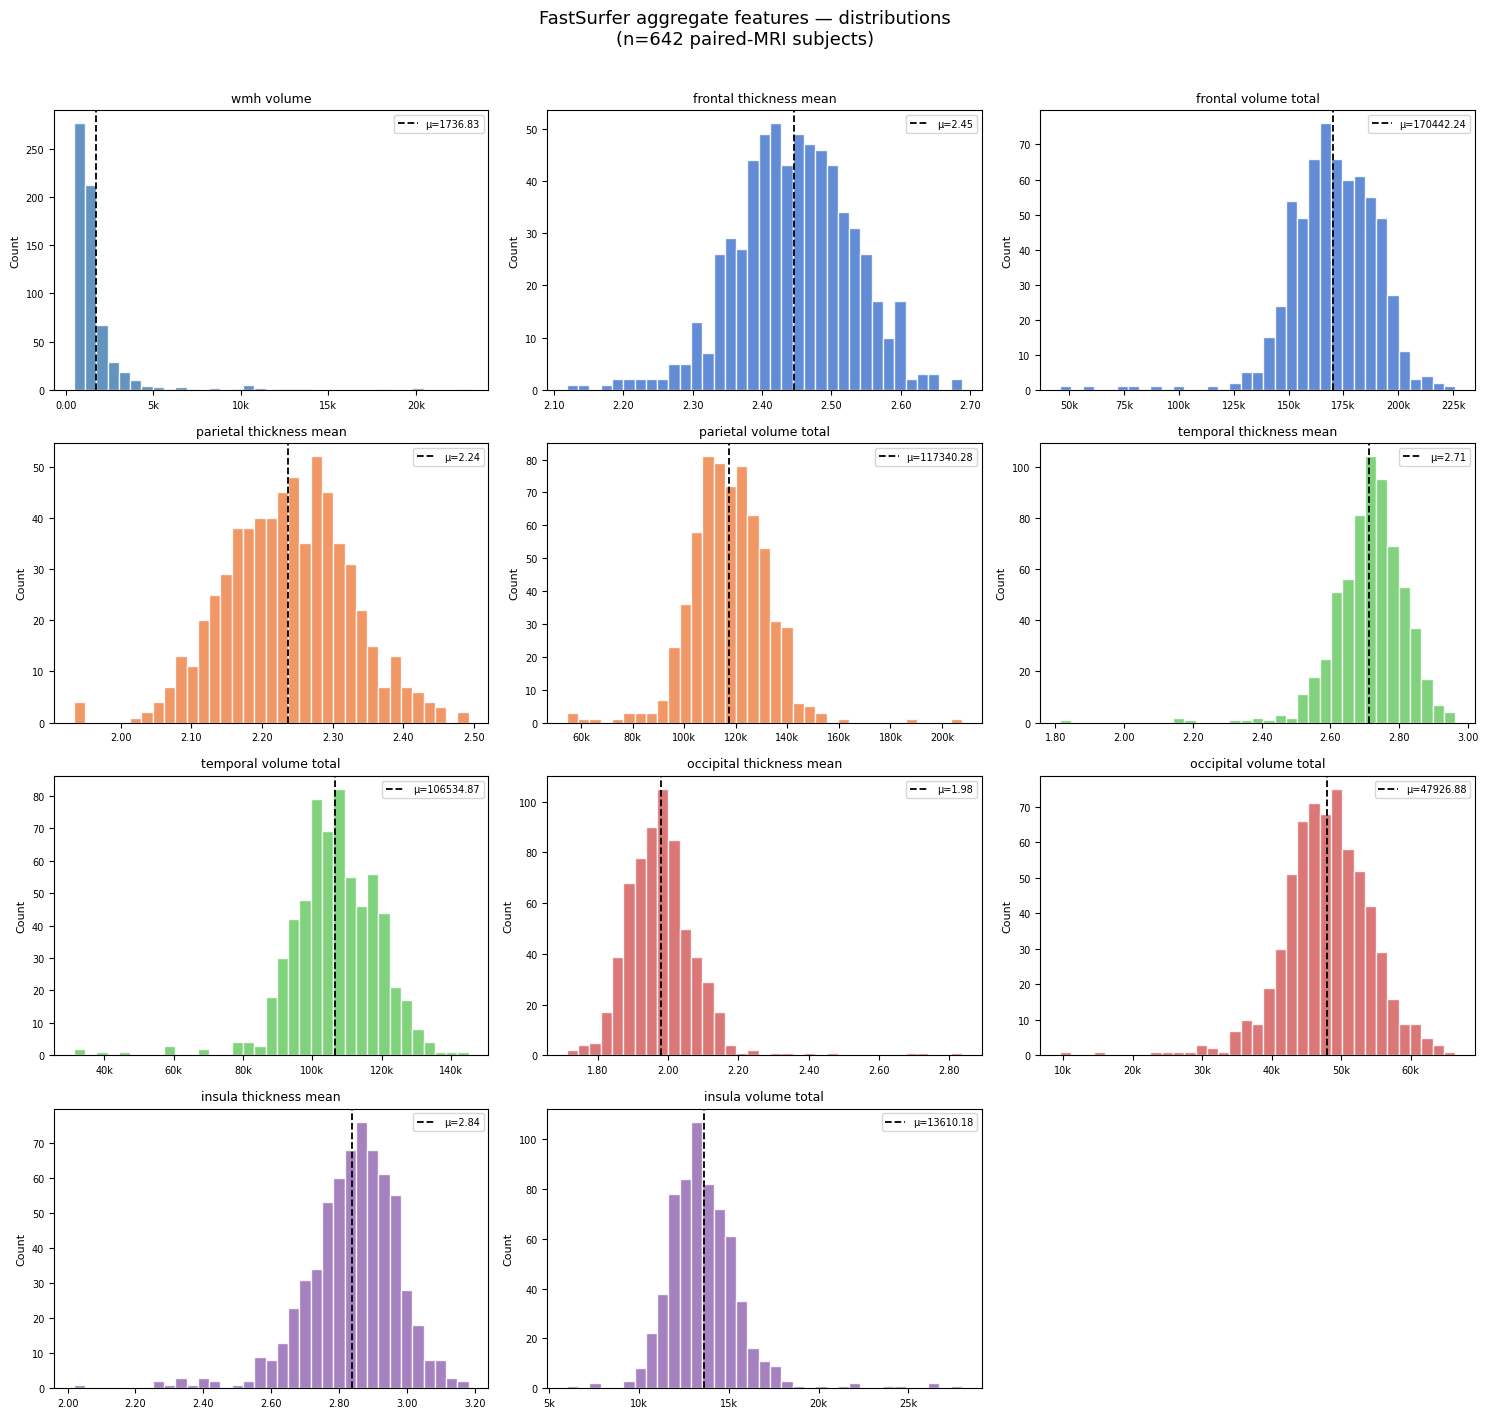

In [8]:
feat_cols = [c for c in df.columns if c != 'mr_hunt_id']
n_feats   = len(feat_cols)          # 11
n_cols    = 3
n_rows    = (n_feats + n_cols - 1) // n_cols   # ceil(11/3) = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))

for ax, col in zip(axes.flat, feat_cols):
    lobe  = next((l for l in LOBES if col.startswith(l)), None)
    color = LOBE_COLORS.get(lobe, 'steelblue')
    data  = df[col].dropna()
    ax.hist(data, bins=35, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='black', linestyle='--', lw=1.3,
               label=f'μ={data.mean():.2f}')
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f'{x/1000:.0f}k' if abs(x) >= 1000 else f'{x:.2f}'))

for ax in axes.flat[n_feats:]:
    ax.set_visible(False)

plt.suptitle('FastSurfer aggregate features — distributions\n'
             f'(n={len(df)} paired-MRI subjects)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Part 5 — Lobe Comparison

Side-by-side comparison of thickness and volume across all five lobes (frontal, parietal, temporal, occipital, insula).

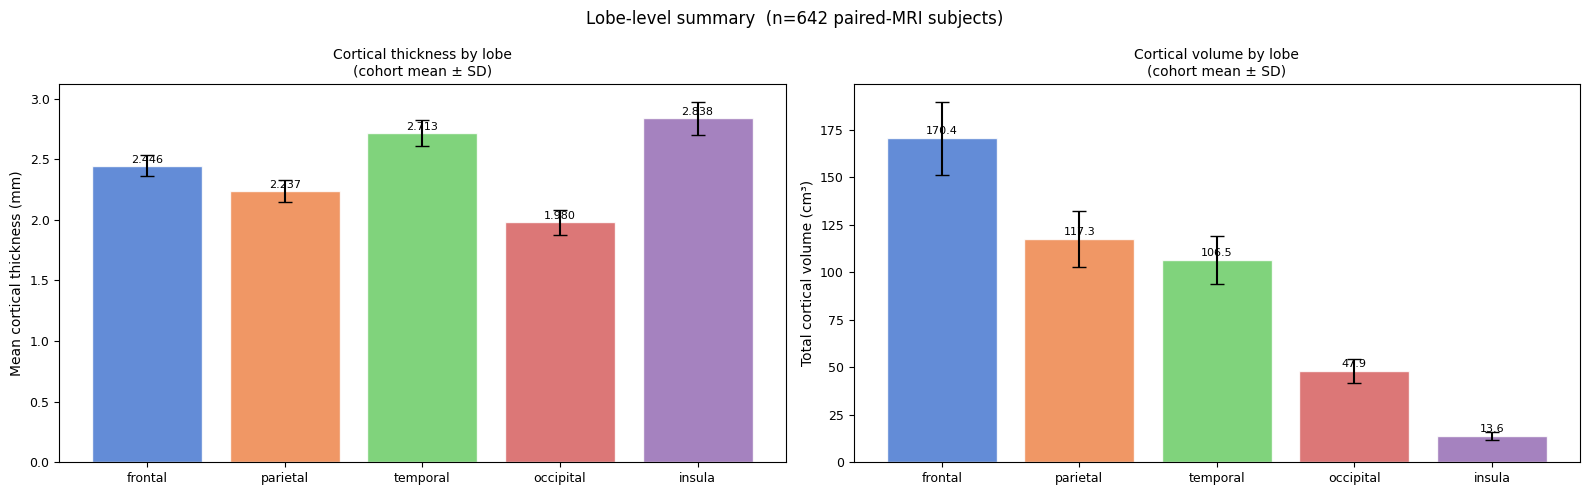

In [9]:
fig, (ax_t, ax_v) = plt.subplots(1, 2, figsize=(16, 5))
colors = [LOBE_COLORS[l] for l in LOBES]

# ── Thickness ──────────────────────────────────────────────────────────
thick_cols = [f'{l}_thickness_mean' for l in LOBES]
means_t = df[thick_cols].mean()
stds_t  = df[thick_cols].std()

bars = ax_t.bar(LOBES, means_t.values, yerr=stds_t.values,
                color=colors, alpha=0.85, capsize=5, edgecolor='white')
ax_t.set_ylabel('Mean cortical thickness (mm)', fontsize=10)
ax_t.set_title('Cortical thickness by lobe\n(cohort mean ± SD)', fontsize=10)
ax_t.tick_params(labelsize=9)
for bar, val in zip(bars, means_t.values):
    ax_t.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + stds_t.max() * 0.06,
              f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# ── Volume ─────────────────────────────────────────────────────────────
vol_cols = [f'{l}_volume_total' for l in LOBES]
means_v = df[vol_cols].mean() / 1000   # mm³ → cm³
stds_v  = df[vol_cols].std()  / 1000

bars = ax_v.bar(LOBES, means_v.values, yerr=stds_v.values,
                color=colors, alpha=0.85, capsize=5, edgecolor='white')
ax_v.set_ylabel('Total cortical volume (cm³)', fontsize=10)
ax_v.set_title('Cortical volume by lobe\n(cohort mean ± SD)', fontsize=10)
ax_v.tick_params(labelsize=9)
for bar, val in zip(bars, means_v.values):
    ax_v.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + stds_v.max() * 0.06,
              f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'Lobe-level summary  (n={len(df)} paired-MRI subjects)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 6 — WMH Volume

`subcort_vol-WM-hypointensities` is the total WM-hypointensity volume reported by FastSurfer (appears hypointense on T1, corresponding to WMH on FLAIR). Distribution is typically right-skewed; both linear and log scale are shown.

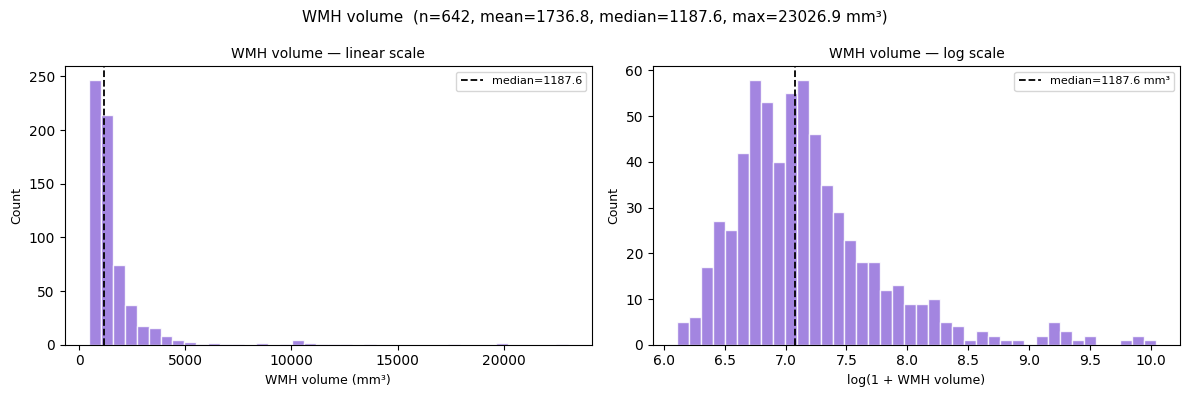

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

wmh = df['wmh_volume'].dropna()

ax1.hist(wmh, bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
ax1.axvline(wmh.median(), color='black', linestyle='--', lw=1.3,
            label=f'median={wmh.median():.1f}')
ax1.set_xlabel('WMH volume (mm³)', fontsize=9)
ax1.set_ylabel('Count', fontsize=9)
ax1.set_title('WMH volume — linear scale', fontsize=10)
ax1.legend(fontsize=8)

ax2.hist(np.log1p(wmh), bins=40, color='mediumpurple', edgecolor='white', alpha=0.85)
ax2.axvline(np.log1p(wmh.median()), color='black', linestyle='--', lw=1.3,
            label=f'median={wmh.median():.1f} mm³')
ax2.set_xlabel('log(1 + WMH volume)', fontsize=9)
ax2.set_ylabel('Count', fontsize=9)
ax2.set_title('WMH volume — log scale', fontsize=10)
ax2.legend(fontsize=8)

plt.suptitle(f'WMH volume  (n={len(wmh)}, mean={wmh.mean():.1f}, '
             f'median={wmh.median():.1f}, max={wmh.max():.1f} mm³)',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## Part 7 — Save

In [11]:
agg.save(OUT_PATH)
print('\nFirst rows of saved file:')
display(pd.read_csv(OUT_PATH, index_col='hunt_id').head(3))

Saved 642 subjects → data/metadata/fastsurfer_aggregated.csv

First rows of saved file:


,mr_hunt_id,wmh_volume,frontal_thickness_mean,frontal_volume_total,parietal_thickness_mean,parietal_volume_total,temporal_thickness_mean,temporal_volume_total,occipital_thickness_mean,occipital_volume_total,insula_thickness_mean,insula_volume_total
hunt_id,,,,,,,,,,,,
22866,9410000000039,958.8,2.450069,152367.0,2.252935,112704.0,2.694750,99947.0,2.004203,45411.0,2.730427,12274.0
10357,9410000000046,1251.1,2.424028,186797.0,2.223160,133773.0,2.645137,109937.0,1.961742,49681.0,2.835887,15683.0
12126,9410000000053,3883.4,2.444520,191664.0,2.239143,118487.0,2.666255,113215.0,1.921432,46785.0,2.801363,16808.0


---
## Part 8 — Normalisation

Min-max scales all 11 feature columns to [0, 1] using cohort-level min/max (same convention as `metadata_normalizer.py`). `mr_hunt_id` is passed through unchanged.

In [12]:
df_norm = agg.normalize()

feat_cols = [c for c in df_norm.columns if c != 'mr_hunt_id']
print('Normalised stats (all features should be in [0, 1]):')
display(df_norm[feat_cols].describe().round(4))

# Verify range
assert df_norm[feat_cols].min().min() >= 0.0
assert df_norm[feat_cols].max().max() <= 1.0
print('\nRange check passed: all features in [0, 1].')

Normalised stats (all features should be in [0, 1]):


,wmh_volume,frontal_thickness_mean,frontal_volume_total,parietal_thickness_mean,parietal_volume_total,temporal_thickness_mean,temporal_volume_total,occipital_thickness_mean,occipital_volume_total,insula_thickness_mean,insula_volume_total
count,642.0000,642.0000,642.0000,642.0000,642.0000,642.0000,642.0000,642.0000,642.0000,642.0000,642.0000
mean,0.0571,0.5748,0.6919,0.5422,0.4102,0.7821,0.6619,0.2384,0.6745,0.7046,0.3468
std,0.0968,0.1477,0.1074,0.1567,0.0966,0.0923,0.1117,0.0926,0.1119,0.1172,0.0952
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0185,0.4827,0.6283,0.4342,0.3507,0.7347,0.6010,0.1817,0.6092,0.6445,0.2896
50%,0.0328,0.5762,0.6905,0.5471,0.4099,0.7891,0.6626,0.2328,0.6781,0.7167,0.3392
75%,0.0555,0.6784,0.7666,0.6479,0.4720,0.8385,0.7385,0.2809,0.7464,0.7835,0.3914
max,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000



Range check passed: all features in [0, 1].


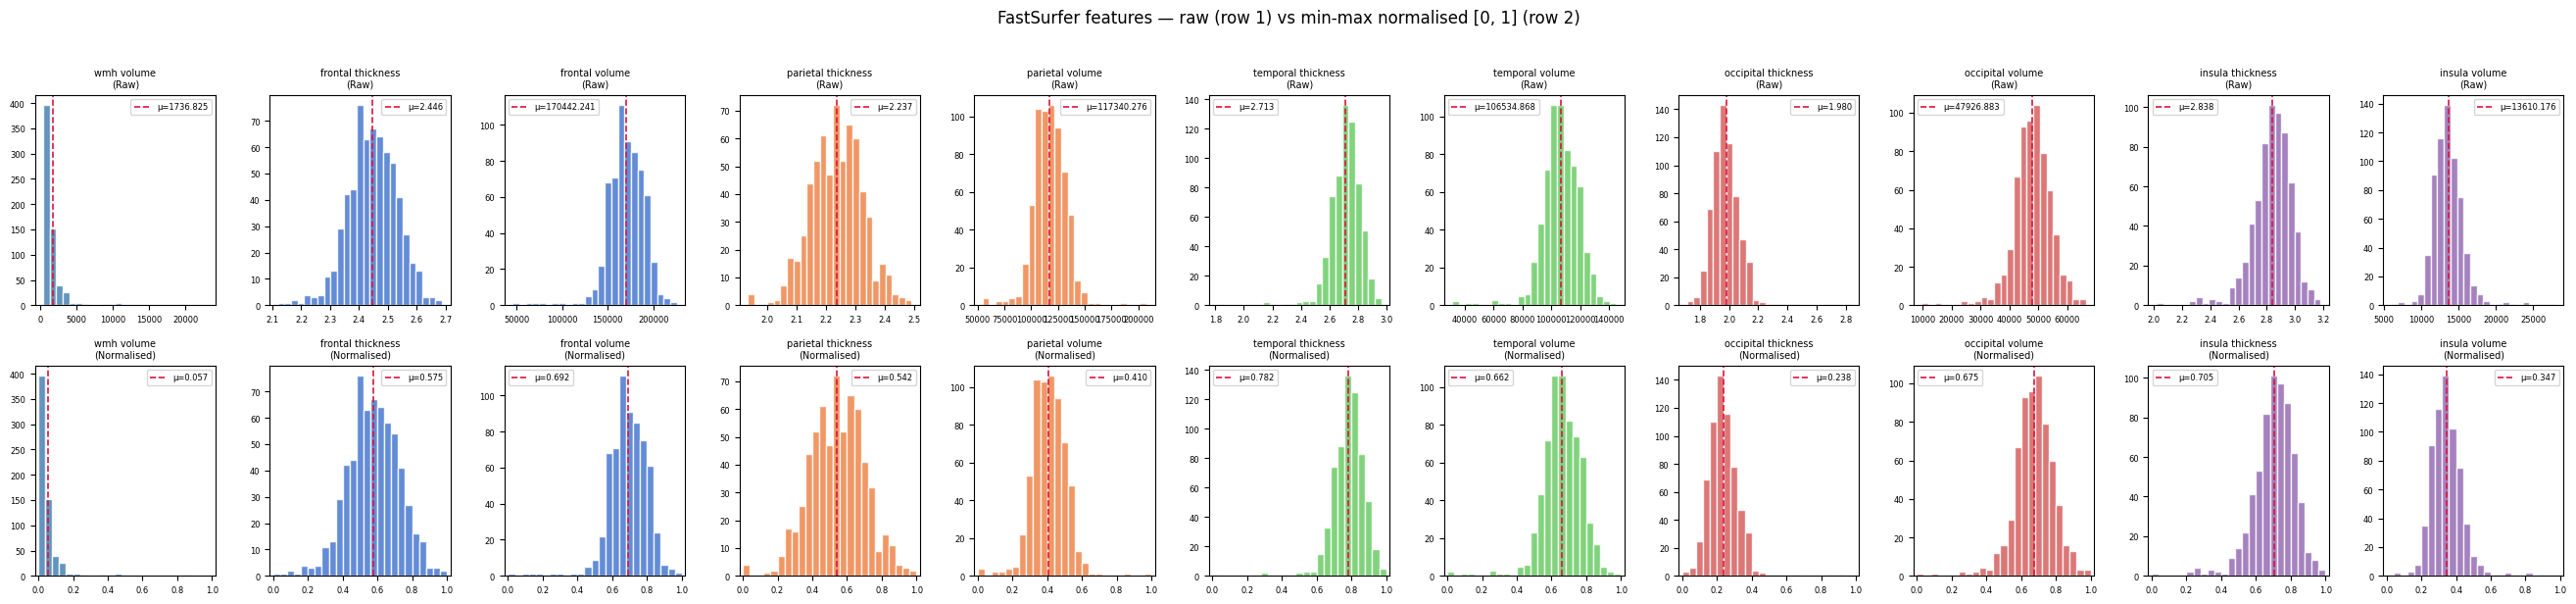

In [13]:
feat_cols = [c for c in df_norm.columns if c != 'mr_hunt_id']

fig, axes = plt.subplots(2, len(feat_cols), figsize=(len(feat_cols) * 2.4, 6))
raw_axes  = axes[0]
norm_axes = axes[1]

for col, ax_r, ax_n in zip(feat_cols, raw_axes, norm_axes):
    lobe  = next((l for l in LOBES if col.startswith(l)), None)
    color = LOBE_COLORS.get(lobe, 'steelblue')
    raw_data  = df[col].dropna()
    norm_data = df_norm[col].dropna()

    for ax, data, row_label in [(ax_r, raw_data, 'Raw'), (ax_n, norm_data, 'Normalised')]:
        ax.hist(data, bins=25, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(data.mean(), color='crimson', linestyle='--', lw=1.2,
                   label=f'μ={data.mean():.3f}')
        short = col.replace('_mean', '').replace('_total', '').replace('_', ' ')
        ax.set_title(f'{short}\n({row_label})', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.legend(fontsize=6)
        if row_label == 'Normalised':
            ax.set_xlim(-0.02, 1.02)

plt.suptitle('FastSurfer features — raw (row 1) vs min-max normalised [0, 1] (row 2)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
agg.save_normalized(OUT_PATH_NORM)
print('\nFirst rows of saved file:')
display(pd.read_csv(OUT_PATH_NORM, index_col='hunt_id').head(3))

Saved 642 subjects (normalized) → data/metadata/fastsurfer_aggregated_normalized.csv

First rows of saved file:


,mr_hunt_id,wmh_volume,frontal_thickness_mean,frontal_volume_total,parietal_thickness_mean,parietal_volume_total,temporal_thickness_mean,temporal_volume_total,occipital_thickness_mean,occipital_volume_total,insula_thickness_mean,insula_volume_total
hunt_id,,,,,,,,,,,,
22866,9410000000039,0.022649,0.581530,0.591519,0.571508,0.379907,0.766420,0.603967,0.260179,0.630277,0.611810,0.286149
10357,9410000000046,0.035594,0.535797,0.782791,0.518232,0.517416,0.723274,0.691759,0.222411,0.705390,0.702383,0.440913
12126,9410000000053,0.152173,0.571785,0.809829,0.546830,0.417651,0.741640,0.720567,0.186556,0.654447,0.672733,0.491987
